# Plot number of shoreline observations per year

## Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

/home/bene/PhD-git/envs/universe/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# matplotlib fontsizes
SMALL_SIZE = 15
MEDIUM_SIZE = 20
BIGGER_SIZE = 25
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)    # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=MEDIUM_SIZE)   # fontsize of the tick labels
plt.rc('ytick', labelsize=MEDIUM_SIZE)   # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)   # legend fontsize
plt.rc('figure', titlesize=MEDIUM_SIZE)  # fontsize of the figure title

In [72]:
path_to_data_folder = '/media/bene/Seagate/PhD-data/98_paper2_kf_dtm/'
path_output = path_to_data_folder + '04_number_of_shorelines_per_year/'

## Data and plots

In [62]:
num_imgs_ters = pd.read_pickle(path_to_data_folder + '12_13_Ters_DEM/output/'+'num_imgs_Ters.pkl')
num_imgs_duck = pd.read_pickle(path_to_data_folder + '22_23_Duck_DEM/output/'+'num_imgs_Duck.pkl')
num_imgs_narra = pd.read_pickle(path_to_data_folder + '32_33_Narrabeen_DEM/output/'+'num_imgs_Narra.pkl')

In [7]:
print('Average, min, max number of images per year:')
print(f'Terschelling: {round(num_imgs_ters['count'].mean())}, {num_imgs_ters['count'].min()}, {num_imgs_ters['count'].max()}')
print(f'Duck: {round(num_imgs_duck['count'].mean())}, {num_imgs_duck['count'].min()}, {num_imgs_duck['count'].max()}')
print(f'Narrabeen: {round(num_imgs_narra['count'].mean())}, {num_imgs_narra['count'].min()}, {num_imgs_narra['count'].max()}')

Average, min, max number of images per year:
Terschelling: 4, 1, 10
Duck: 10, 1, 16
Narrabeen: 11, 3, 20


In [63]:
num_imgs_ters.index = num_imgs_ters[0]
num_imgs_ters = num_imgs_ters.drop(columns=[0])

num_imgs_ters.loc[2002] = 0
num_imgs_ters.loc[2012] = 0
num_imgs_ters = num_imgs_ters.sort_values(0)

In [64]:
num_imgs_duck.index = num_imgs_duck[0]
num_imgs_duck = num_imgs_duck.drop(columns=[0])

num_imgs_duck.loc[2012] = 0
num_imgs_duck = num_imgs_duck.sort_values(0)

In [65]:
num_imgs_narra.index = num_imgs_narra[0]
num_imgs_narra = num_imgs_narra.drop(columns=[0])

num_imgs_narra.loc[2000] = 0
num_imgs_narra.loc[2001] = 0
num_imgs_narra.loc[2002] = 0
num_imgs_narra.loc[2012] = 0
num_imgs_narra = num_imgs_narra.sort_values(0)

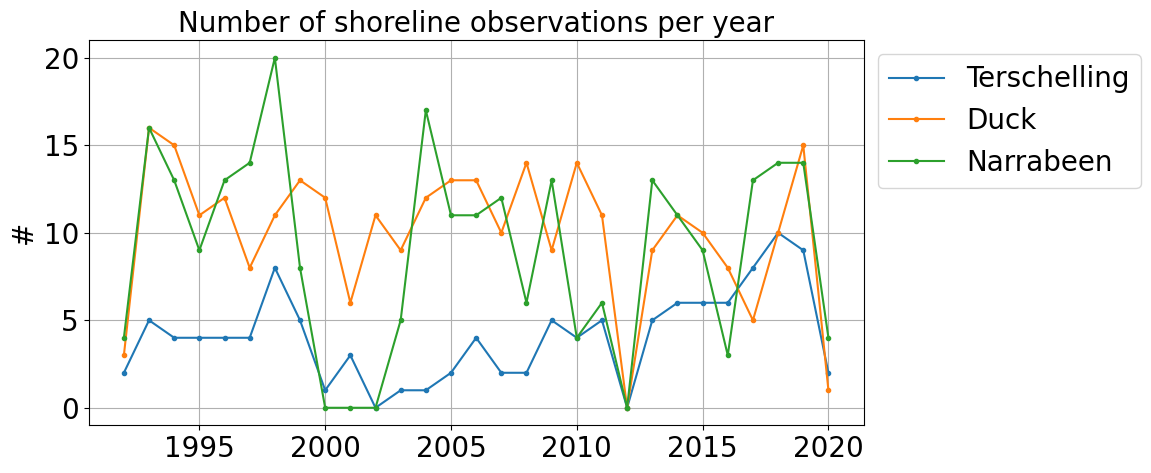

In [73]:
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(num_imgs_ters.index, num_imgs_ters['count'], '.-', label='Terschelling')
ax.plot(num_imgs_duck.index, num_imgs_duck['count'], '.-', label='Duck')
ax.plot(num_imgs_narra.index, num_imgs_narra['count'], '.-', label='Narrabeen')
ax.set_title('Number of shoreline observations per year')
ax.set_ylabel('#')
ax.legend(bbox_to_anchor=(1,1))
ax.grid()

plt.savefig(f'{path_output}_number_of_shorelines_per_year.png', dpi=300, bbox_inches='tight')